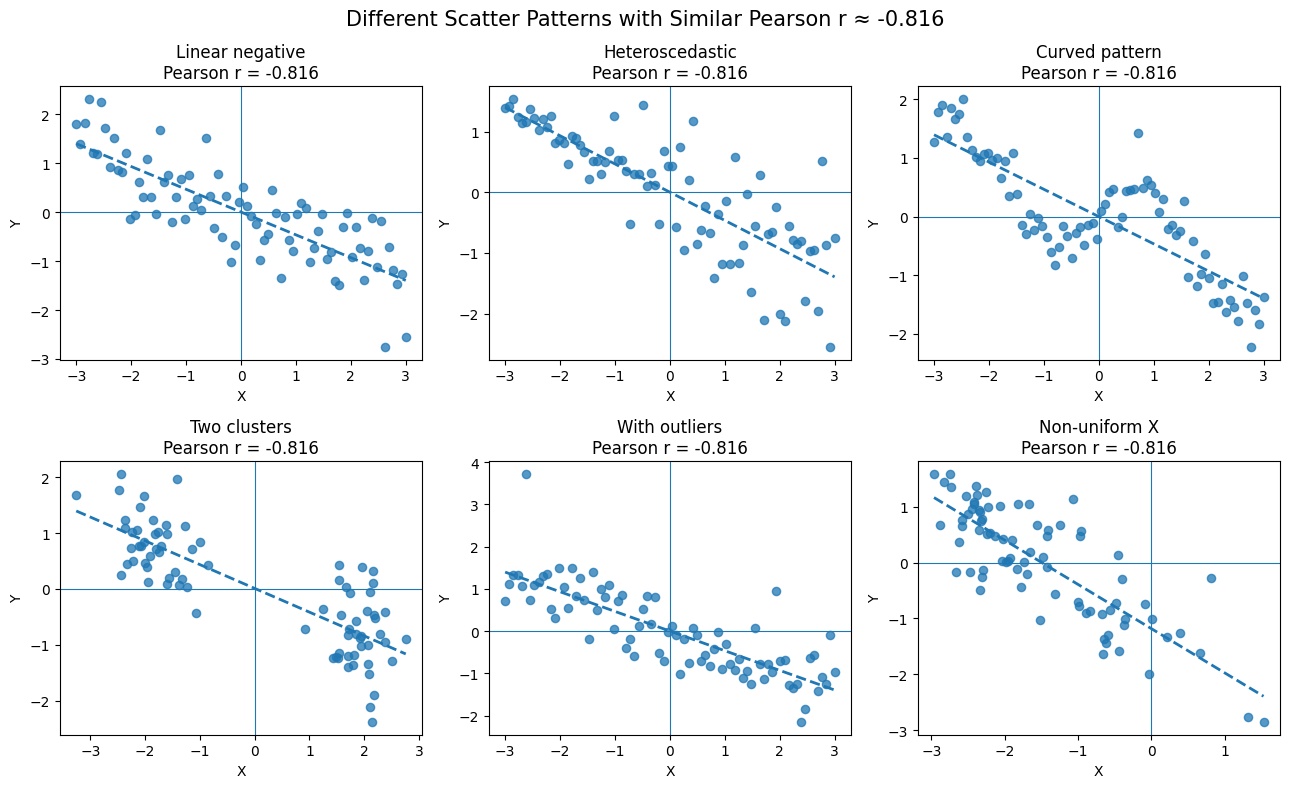

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ============================================================
# Helper: adjust y so that corr(x, y) is exactly close to target_r
# ============================================================

def make_y_with_target_corr(x, z, target_r=-0.816):
    """
    Construct y with approximately target Pearson correlation with x.

    x: base x variable
    z: arbitrary shape/noise variable, will be orthogonalized to x
    """

    x = np.asarray(x)
    z = np.asarray(z)

    # Standardize x
    x_std = (x - x.mean()) / x.std()

    # Remove the linear component of z related to x
    z_std = (z - z.mean()) / z.std()
    z_orth = z_std - np.corrcoef(x_std, z_std)[0, 1] * x_std
    z_orth = (z_orth - z_orth.mean()) / z_orth.std()

    # Combine x and orthogonal noise to control Pearson r
    y = target_r * x_std + np.sqrt(1 - target_r**2) * z_orth

    return y


# ============================================================
# Generate multiple examples
# ============================================================

np.random.seed(42)

target_r = -0.816
n = 80

examples = []

# 1. Classic linear negative relationship
x1 = np.linspace(-3, 3, n)
z1 = np.random.normal(0, 1, n)
y1 = make_y_with_target_corr(x1, z1, target_r)
examples.append(("Linear negative", x1, y1))

# 2. Heteroscedastic: noise increases with x
x2 = np.linspace(-3, 3, n)
z2 = np.random.normal(0, 1, n) * (0.3 + 0.4 * (x2 - x2.min()))
y2 = make_y_with_target_corr(x2, z2, target_r)
examples.append(("Heteroscedastic", x2, y2))

# 3. Curved but still strong negative linear trend
x3 = np.linspace(-3, 3, n)
z3 = 0.8 * np.sin(1.8 * x3) + np.random.normal(0, 0.35, n)
y3 = make_y_with_target_corr(x3, z3, target_r)
examples.append(("Curved pattern", x3, y3))

# 4. Two clusters / grouped distribution
x4 = np.concatenate([
    np.random.normal(-1.8, 0.45, n // 2),
    np.random.normal(1.8, 0.45, n // 2)
])
z4 = np.random.normal(0, 1, n)
y4 = make_y_with_target_corr(x4, z4, target_r)
examples.append(("Two clusters", x4, y4))

# 5. With a few outliers
x5 = np.linspace(-3, 3, n)
z5 = np.random.normal(0, 0.9, n)
y5 = make_y_with_target_corr(x5, z5, target_r)

# Add mild visual outliers, then re-adjust correlation
z5_outlier = y5.copy()
z5_outlier[[5, 20, 65]] += np.array([2.8, -2.2, 2.5])
y5 = make_y_with_target_corr(x5, z5_outlier, target_r)
examples.append(("With outliers", x5, y5))

# 6. Non-uniform x distribution
x6 = np.sort(np.random.beta(1.5, 4.5, n)) * 6 - 3
z6 = np.random.normal(0, 1, n)
y6 = make_y_with_target_corr(x6, z6, target_r)
examples.append(("Non-uniform X", x6, y6))


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()

for ax, (title, x, y) in zip(axes, examples):

    r, p = pearsonr(x, y)

    # Linear fit
    coef = np.polyfit(x, y, 1)
    fit = np.poly1d(coef)

    ax.scatter(x, y, s=35, alpha=0.75)
    ax.plot(
        np.sort(x),
        fit(np.sort(x)),
        linestyle="--",
        linewidth=2
    )

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_title(f"{title}\nPearson r = {r:.3f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.suptitle("Different Scatter Patterns with Similar Pearson r ≈ -0.816", fontsize=15)
plt.tight_layout()
plt.show()

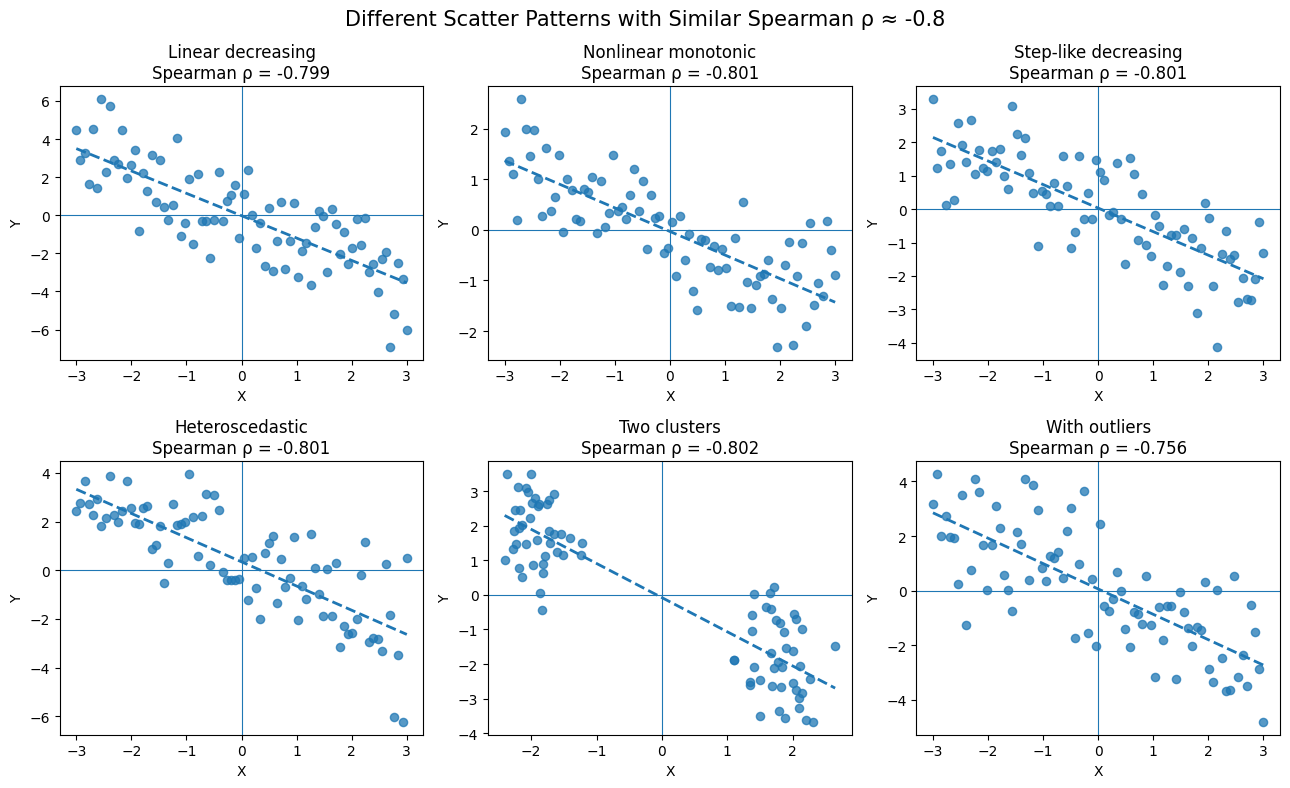

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# ============================================================
# Helper: search noise scale so Spearman rho is close to target
# ============================================================

def tune_spearman_example(x, base_curve_func, target_rho=-0.8, seed=0):
    """
    Generate y from a base decreasing curve plus noise,
    and tune noise level so Spearman rho is close to target_rho.
    """

    rng = np.random.default_rng(seed)

    best = None
    best_diff = np.inf

    noise_scales = np.linspace(0.05, 2.5, 200)

    for scale in noise_scales:
        noise = rng.normal(0, scale, len(x))
        y = base_curve_func(x) + noise

        rho, _ = spearmanr(x, y)
        diff = abs(rho - target_rho)

        if diff < best_diff:
            best_diff = diff
            best = (y, rho, scale)

    return best


# ============================================================
# Generate multiple examples
# ============================================================

np.random.seed(42)

target_rho = -0.8
n = 80
examples = []

# 1. Almost linear decreasing pattern
x1 = np.linspace(-3, 3, n)

y1, rho1, scale1 = tune_spearman_example(
    x1,
    lambda x: -x,
    target_rho=target_rho,
    seed=1
)
examples.append(("Linear decreasing", x1, y1))

# 2. Nonlinear monotonic decreasing pattern
x2 = np.linspace(-3, 3, n)

y2, rho2, scale2 = tune_spearman_example(
    x2,
    lambda x: -np.tanh(1.2 * x),
    target_rho=target_rho,
    seed=2
)
examples.append(("Nonlinear monotonic", x2, y2))

# 3. Step-like decreasing pattern
x3 = np.linspace(-3, 3, n)

def step_curve(x):
    return np.piecewise(
        x,
        [x < -1.2, (x >= -1.2) & (x < 0.8), x >= 0.8],
        [2.0, 0.2, -1.6]
    )

y3, rho3, scale3 = tune_spearman_example(
    x3,
    step_curve,
    target_rho=target_rho,
    seed=3
)
examples.append(("Step-like decreasing", x3, y3))

# 4. Heteroscedastic pattern: wider spread on the right
x4 = np.linspace(-3, 3, n)
rng4 = np.random.default_rng(4)

best_y4 = None
best_diff4 = np.inf

for scale in np.linspace(0.05, 2.5, 200):
    noise = rng4.normal(0, scale * (0.4 + 0.25 * (x4 - x4.min())), n)
    y = -x4 + noise
    rho, _ = spearmanr(x4, y)

    if abs(rho - target_rho) < best_diff4:
        best_diff4 = abs(rho - target_rho)
        best_y4 = y

examples.append(("Heteroscedastic", x4, best_y4))

# 5. Two-cluster decreasing pattern
rng5 = np.random.default_rng(5)

x5 = np.concatenate([
    rng5.normal(-1.8, 0.35, n // 2),
    rng5.normal(1.8, 0.35, n // 2)
])

y5, rho5, scale5 = tune_spearman_example(
    x5,
    lambda x: -x,
    target_rho=target_rho,
    seed=5
)
examples.append(("Two clusters", x5, y5))

# 6. Decreasing pattern with outliers
x6 = np.linspace(-3, 3, n)

y6, rho6, scale6 = tune_spearman_example(
    x6,
    lambda x: -x,
    target_rho=target_rho,
    seed=6
)

# Add visible outliers, then tune again using the outlier-shaped base
y6_base = y6.copy()
y6_base[[8, 22, 65]] += np.array([-3.0, 2.5, 3.0])

def outlier_base_curve(x):
    return y6_base

# For this one, keep the modified y if close enough; otherwise use it directly
rho6_new, _ = spearmanr(x6, y6_base)

if abs(rho6_new - target_rho) < 0.08:
    y6 = y6_base

examples.append(("With outliers", x6, y6))


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()

for ax, (title, x, y) in zip(axes, examples):

    rho, p = spearmanr(x, y)

    # Linear fit is only for visual reference
    coef = np.polyfit(x, y, 1)
    fit = np.poly1d(coef)

    ax.scatter(x, y, s=35, alpha=0.75)
    ax.plot(
        np.sort(x),
        fit(np.sort(x)),
        linestyle="--",
        linewidth=2,
        label="Linear reference"
    )

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_title(f"{title}\nSpearman ρ = {rho:.3f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.suptitle("Different Scatter Patterns with Similar Spearman ρ ≈ -0.8", fontsize=15)
plt.tight_layout()
plt.show()

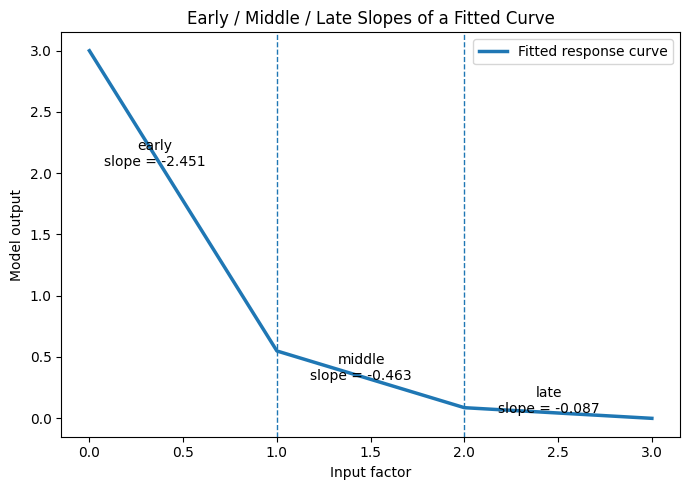

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Example: early / middle / late slopes
# ============================================================

early_slope = -2.451
middle_slope = -0.463
late_slope = -0.087

# Three x stages
x1 = np.linspace(0, 1, 40)
x2 = np.linspace(1, 2, 40)
x3 = np.linspace(2, 3, 40)

# Build piecewise curve
y0 = 3.0

y1 = y0 + early_slope * (x1 - x1[0])
y1_end = y1[-1]

y2 = y1_end + middle_slope * (x2 - x2[0])
y2_end = y2[-1]

y3 = y2_end + late_slope * (x3 - x3[0])

x = np.concatenate([x1, x2, x3])
y = np.concatenate([y1, y2, y3])

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(x, y, linewidth=2.5, label="Fitted response curve")

# Stage boundaries
plt.axvline(1, linestyle="--", linewidth=1)
plt.axvline(2, linestyle="--", linewidth=1)

# Add stage labels
plt.text(0.35, y1[15], "early\nslope = -2.451", ha="center")
plt.text(1.45, y2[20], "middle\nslope = -0.463", ha="center")
plt.text(2.45, y3[20], "late\nslope = -0.087", ha="center")

plt.xlabel("Input factor")
plt.ylabel("Model output")
plt.title("Early / Middle / Late Slopes of a Fitted Curve")

plt.legend()
plt.tight_layout()
plt.show()

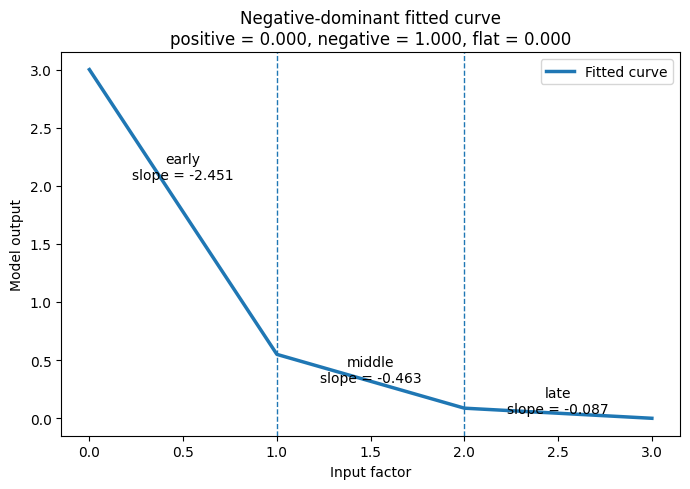

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Fractions
positive_fraction = 0.000
negative_fraction = 1.000
flat_fraction = 0.000

# Slopes
early_slope = -2.451
middle_slope = -0.463
late_slope = -0.087

# Build a fitted curve with three slope stages
x1 = np.linspace(0, 1, 40)
x2 = np.linspace(1, 2, 40)
x3 = np.linspace(2, 3, 40)

y0 = 3.0

y1 = y0 + early_slope * (x1 - x1[0])
y2 = y1[-1] + middle_slope * (x2 - x2[0])
y3 = y2[-1] + late_slope * (x3 - x3[0])

x = np.concatenate([x1, x2, x3])
y = np.concatenate([y1, y2, y3])

plt.figure(figsize=(7, 5))

plt.plot(x, y, linewidth=2.5, label="Fitted curve")

plt.axvline(1, linestyle="--", linewidth=1)
plt.axvline(2, linestyle="--", linewidth=1)

plt.text(0.5, y1[15], "early\nslope = -2.451", ha="center")
plt.text(1.5, y2[20], "middle\nslope = -0.463", ha="center")
plt.text(2.5, y3[20], "late\nslope = -0.087", ha="center")

plt.xlabel("Input factor")
plt.ylabel("Model output")
plt.title(
    "Negative-dominant fitted curve\n"
    "positive = 0.000, negative = 1.000, flat = 0.000"
)

plt.legend()
plt.tight_layout()
plt.show()

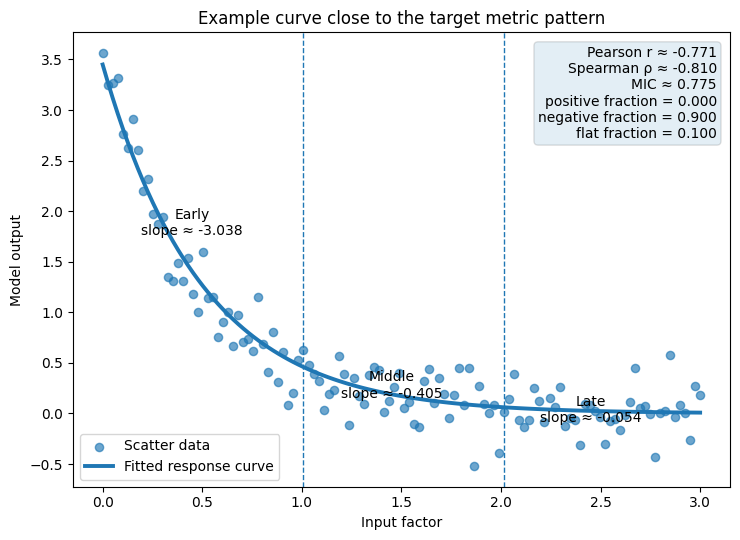

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# Optional: MIC
# pip install minepy
try:
    from minepy import MINE
    HAS_MINEPY = True
except ImportError:
    HAS_MINEPY = False


# ============================================================
# 1. Helper functions
# ============================================================

def calculate_mic(x, y):
    if not HAS_MINEPY:
        return np.nan

    mine = MINE(alpha=0.6, c=15)
    mine.compute_score(x, y)
    return mine.mic()


def calculate_shape_fractions(x, y, slope_tol=0.03):
    """
    Calculate positive / negative / flat fraction from local slopes.
    """
    slopes = np.gradient(y, x)

    positive_fraction = np.mean(slopes > slope_tol)
    negative_fraction = np.mean(slopes < -slope_tol)
    flat_fraction = np.mean(np.abs(slopes) <= slope_tol)

    return positive_fraction, negative_fraction, flat_fraction, slopes


def calculate_stage_slopes(x, y):
    """
    Calculate early / middle / late mean slopes.
    """
    slopes = np.gradient(y, x)

    n = len(slopes)
    early = slopes[: n // 3]
    middle = slopes[n // 3 : 2 * n // 3]
    late = slopes[2 * n // 3 :]

    return early.mean(), middle.mean(), late.mean()


# ============================================================
# 2. Generate a curve close to the target metrics
# ============================================================

np.random.seed(42)

n = 120
x = np.linspace(0, 3, n)

# A monotonic saturating decreasing curve
# Large negative slope at the beginning, then gradually flattening
base_y = 3.0 * np.exp(-2.0 * x)

# Add moderate noise to make Pearson / Spearman around -0.8
noise = np.random.normal(0, 0.23, n)

y_raw = base_y + noise

# Enforce an overall decreasing fitted curve for shape metrics
# This fitted curve represents the response curve, not raw scatter
y_fit = 3.0 * np.exp(-2.0 * x)

# Rescale fitted curve so its stage slopes are close to:
# early = -2.451, middle = -0.463, late = -0.087
scale = 1.15
y_fit = scale * y_fit

# Scatter points around the fitted curve
y_scatter = y_fit + noise


# ============================================================
# 3. Calculate metrics
# ============================================================

pearson_r, _ = pearsonr(x, y_scatter)
spearman_rho, _ = spearmanr(x, y_scatter)
mic_value = calculate_mic(x, y_scatter)

pos_frac, neg_frac, flat_frac, slopes = calculate_shape_fractions(
    x, y_fit,
    slope_tol=0.03
)

early_slope, middle_slope, late_slope = calculate_stage_slopes(x, y_fit)


# ============================================================
# 4. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.scatter(
    x,
    y_scatter,
    s=35,
    alpha=0.65,
    label="Scatter data"
)

ax.plot(
    x,
    y_fit,
    linewidth=2.8,
    label="Fitted response curve"
)

# Stage boundaries
ax.axvline(x[len(x)//3], linestyle="--", linewidth=1)
ax.axvline(x[2*len(x)//3], linestyle="--", linewidth=1)

# Stage labels
ax.text(
    0.45,
    y_fit[12],
    f"Early\nslope ≈ {early_slope:.3f}",
    ha="center",
    va="center"
)

ax.text(
    1.45,
    y_fit[50],
    f"Middle\nslope ≈ {middle_slope:.3f}",
    ha="center",
    va="center"
)

ax.text(
    2.45,
    y_fit[92],
    f"Late\nslope ≈ {late_slope:.3f}",
    ha="center",
    va="center"
)

# Metric annotation
metric_text = (
    f"Pearson r ≈ {pearson_r:.3f}\n"
    f"Spearman ρ ≈ {spearman_rho:.3f}\n"
)

if HAS_MINEPY:
    metric_text += f"MIC ≈ {mic_value:.3f}\n"
else:
    metric_text += "MIC: install minepy to compute\n"

metric_text += (
    f"positive fraction = {pos_frac:.3f}\n"
    f"negative fraction = {neg_frac:.3f}\n"
    f"flat fraction = {flat_frac:.3f}"
)

ax.text(
    0.98,
    0.97,
    metric_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.12)
)

ax.set_xlabel("Input factor")
ax.set_ylabel("Model output")
ax.set_title("Example curve close to the target metric pattern")

ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

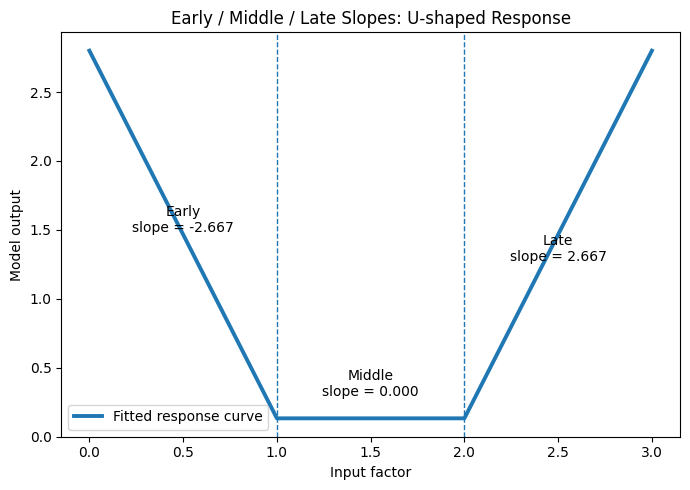

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Early / middle / late slopes
# ============================================================

early_slope = -2.667
middle_slope = 0.000
late_slope = 2.667

# Three stages
x1 = np.linspace(0, 1, 40)
x2 = np.linspace(1, 2, 40)
x3 = np.linspace(2, 3, 40)

# Build piecewise fitted curve
y0 = 2.8

y1 = y0 + early_slope * (x1 - x1[0])
y2 = y1[-1] + middle_slope * (x2 - x2[0])
y3 = y2[-1] + late_slope * (x3 - x3[0])

x = np.concatenate([x1, x2, x3])
y = np.concatenate([y1, y2, y3])

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(x, y, linewidth=2.8, label="Fitted response curve")

# Stage boundaries
plt.axvline(1, linestyle="--", linewidth=1)
plt.axvline(2, linestyle="--", linewidth=1)

# Stage labels
plt.text(
    0.5, y1[18],
    "Early\nslope = -2.667",
    ha="center",
    va="center"
)

plt.text(
    1.5, y2[20] + 0.25,
    "Middle\nslope = 0.000",
    ha="center",
    va="center"
)

plt.text(
    2.5, y3[18],
    "Late\nslope = 2.667",
    ha="center",
    va="center"
)

plt.xlabel("Input factor")
plt.ylabel("Model output")
plt.title("Early / Middle / Late Slopes: U-shaped Response")

plt.legend()
plt.tight_layout()
plt.show()

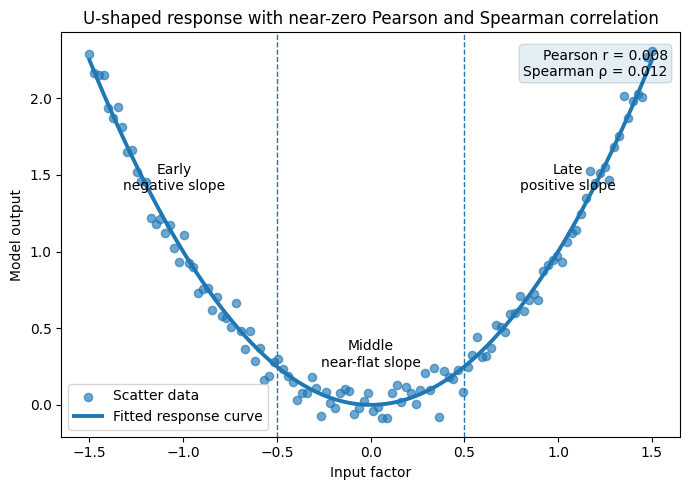

Pearson r = 0.008
Spearman rho = 0.012


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

np.random.seed(42)

# ============================================================
# Generate a symmetric U-shaped curve
# ============================================================

n = 120
x = np.linspace(-1.5, 1.5, n)

# U-shaped fitted curve
y_fit = x**2

# Add mild noise for scatter points
noise = np.random.normal(0, 0.08, n)
y_scatter = y_fit + noise

# Calculate Pearson and Spearman
pearson_r, _ = pearsonr(x, y_scatter)
spearman_rho, _ = spearmanr(x, y_scatter)

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    x,
    y_scatter,
    s=35,
    alpha=0.65,
    label="Scatter data"
)

plt.plot(
    x,
    y_fit,
    linewidth=2.8,
    label="Fitted response curve"
)

plt.axvline(-0.5, linestyle="--", linewidth=1)
plt.axvline(0.5, linestyle="--", linewidth=1)

plt.text(
    -1.05,
    1.4,
    "Early\nnegative slope",
    ha="center"
)

plt.text(
    0,
    0.25,
    "Middle\nnear-flat slope",
    ha="center"
)

plt.text(
    1.05,
    1.4,
    "Late\npositive slope",
    ha="center"
)

plt.text(
    0.98,
    0.96,
    f"Pearson r = {pearson_r:.3f}\nSpearman ρ = {spearman_rho:.3f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round", alpha=0.12)
)

plt.xlabel("Input factor")
plt.ylabel("Model output")
plt.title("U-shaped response with near-zero Pearson and Spearman correlation")

plt.legend()
plt.tight_layout()
plt.show()

print(f"Pearson r = {pearson_r:.3f}")
print(f"Spearman rho = {spearman_rho:.3f}")

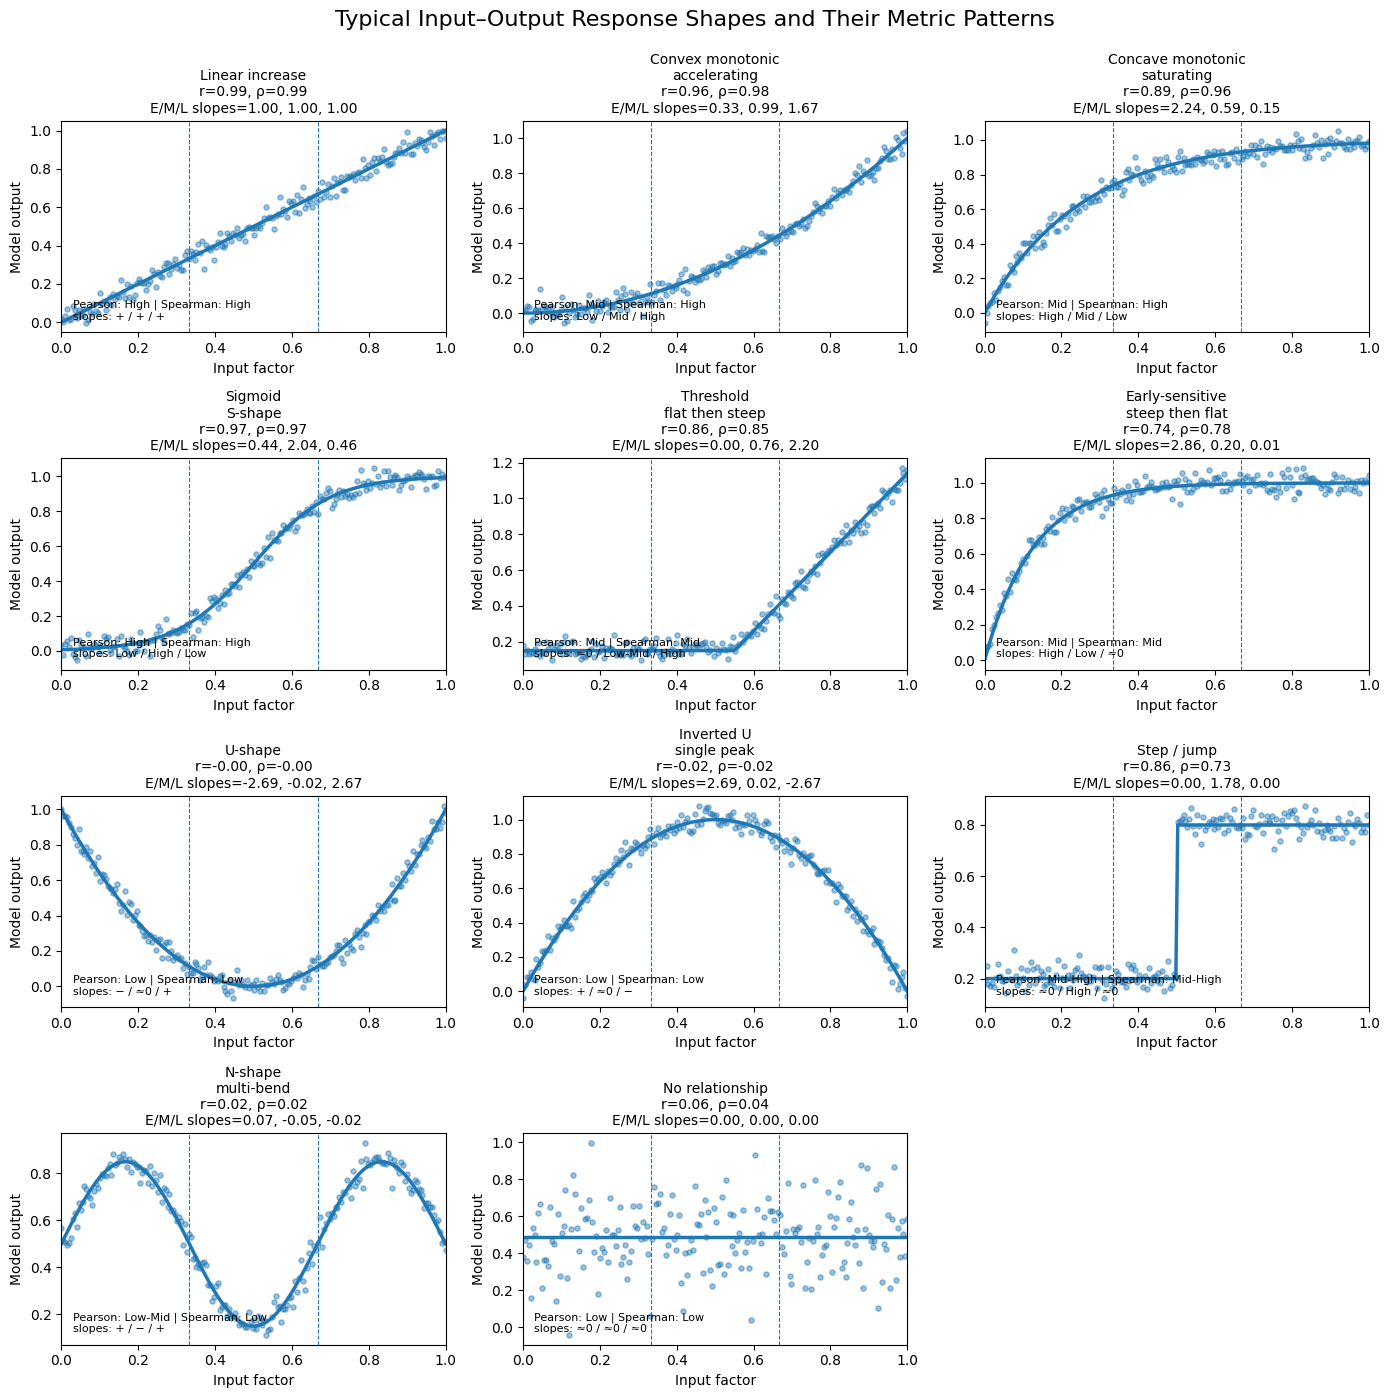

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ============================================================
# 1. Generate example curves for each shape
# ============================================================

np.random.seed(42)

x = np.linspace(0, 1, 200)

shape_funcs = {
    "Linear increase": lambda x: x,
    "Convex monotonic\naccelerating": lambda x: x**2,
    "Concave monotonic\nsaturating": lambda x: 1 - np.exp(-4 * x),
    "Sigmoid\nS-shape": lambda x: 1 / (1 + np.exp(-10 * (x - 0.5))),
    "Threshold\nflat then steep": lambda x: np.where(x < 0.55, 0.15, 0.15 + 2.2 * (x - 0.55)),
    "Early-sensitive\nsteep then flat": lambda x: 1 - np.exp(-8 * x),
    "U-shape": lambda x: 4 * (x - 0.5)**2,
    "Inverted U\nsingle peak": lambda x: -4 * (x - 0.5)**2 + 1,
    "Step / jump": lambda x: np.where(x < 0.5, 0.2, 0.8),
    "N-shape\nmulti-bend": lambda x: 0.5 + 0.35 * np.sin(3 * np.pi * x),
    "No relationship": lambda x: np.random.normal(0.5, 0.18, len(x)),
}

# Table-like qualitative labels
shape_notes = {
    "Linear increase": "Pearson: High | Spearman: High\nslopes: + / + / +",
    "Convex monotonic\naccelerating": "Pearson: Mid | Spearman: High\nslopes: Low / Mid / High",
    "Concave monotonic\nsaturating": "Pearson: Mid | Spearman: High\nslopes: High / Mid / Low",
    "Sigmoid\nS-shape": "Pearson: High | Spearman: High\nslopes: Low / High / Low",
    "Threshold\nflat then steep": "Pearson: Mid | Spearman: Mid\nslopes: ≈0 / Low-Mid / High",
    "Early-sensitive\nsteep then flat": "Pearson: Mid | Spearman: Mid\nslopes: High / Low / ≈0",
    "U-shape": "Pearson: Low | Spearman: Low\nslopes: − / ≈0 / +",
    "Inverted U\nsingle peak": "Pearson: Low | Spearman: Low\nslopes: + / ≈0 / −",
    "Step / jump": "Pearson: Mid-High | Spearman: Mid-High\nslopes: ≈0 / High / ≈0",
    "N-shape\nmulti-bend": "Pearson: Low-Mid | Spearman: Low\nslopes: + / − / +",
    "No relationship": "Pearson: Low | Spearman: Low\nslopes: ≈0 / ≈0 / ≈0",
}


# ============================================================
# 2. Helper: calculate early / middle / late slopes
# ============================================================

def stage_slopes(x, y):
    slopes = np.gradient(y, x)

    n = len(slopes)
    early = slopes[: n // 3].mean()
    middle = slopes[n // 3 : 2 * n // 3].mean()
    late = slopes[2 * n // 3 :].mean()

    return early, middle, late


# ============================================================
# 3. Plot all shapes
# ============================================================

fig, axes = plt.subplots(4, 3, figsize=(14, 14))
axes = axes.ravel()

for ax, (shape_name, func) in zip(axes, shape_funcs.items()):

    y_true = func(x)

    # Add light noise for scatter, except for no relationship
    if shape_name == "No relationship":
        y_scatter = y_true
        y_fit = np.full_like(x, np.mean(y_true))
    else:
        noise = np.random.normal(0, 0.035, len(x))
        y_scatter = y_true + noise
        y_fit = y_true

    pearson_r, _ = pearsonr(x, y_scatter)
    spearman_rho, _ = spearmanr(x, y_scatter)

    early, middle, late = stage_slopes(x, y_fit)

    ax.scatter(x, y_scatter, s=14, alpha=0.45)
    ax.plot(x, y_fit, linewidth=2.5)

    # Divide into early / middle / late stages
    ax.axvline(1/3, linestyle="--", linewidth=0.8)
    ax.axvline(2/3, linestyle="--", linewidth=0.8)

    ax.set_title(
        f"{shape_name}\n"
        f"r={pearson_r:.2f}, ρ={spearman_rho:.2f}\n"
        f"E/M/L slopes={early:.2f}, {middle:.2f}, {late:.2f}",
        fontsize=10
    )

    ax.text(
        0.03,
        0.05,
        shape_notes[shape_name],
        transform=ax.transAxes,
        fontsize=8,
        va="bottom"
    )

    ax.set_xlim(0, 1)
    ax.set_xlabel("Input factor")
    ax.set_ylabel("Model output")

# Hide the last empty panel
for j in range(len(shape_funcs), len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Typical Input–Output Response Shapes and Their Metric Patterns",
    fontsize=16,
    y=0.995
)

plt.tight_layout()
plt.show()

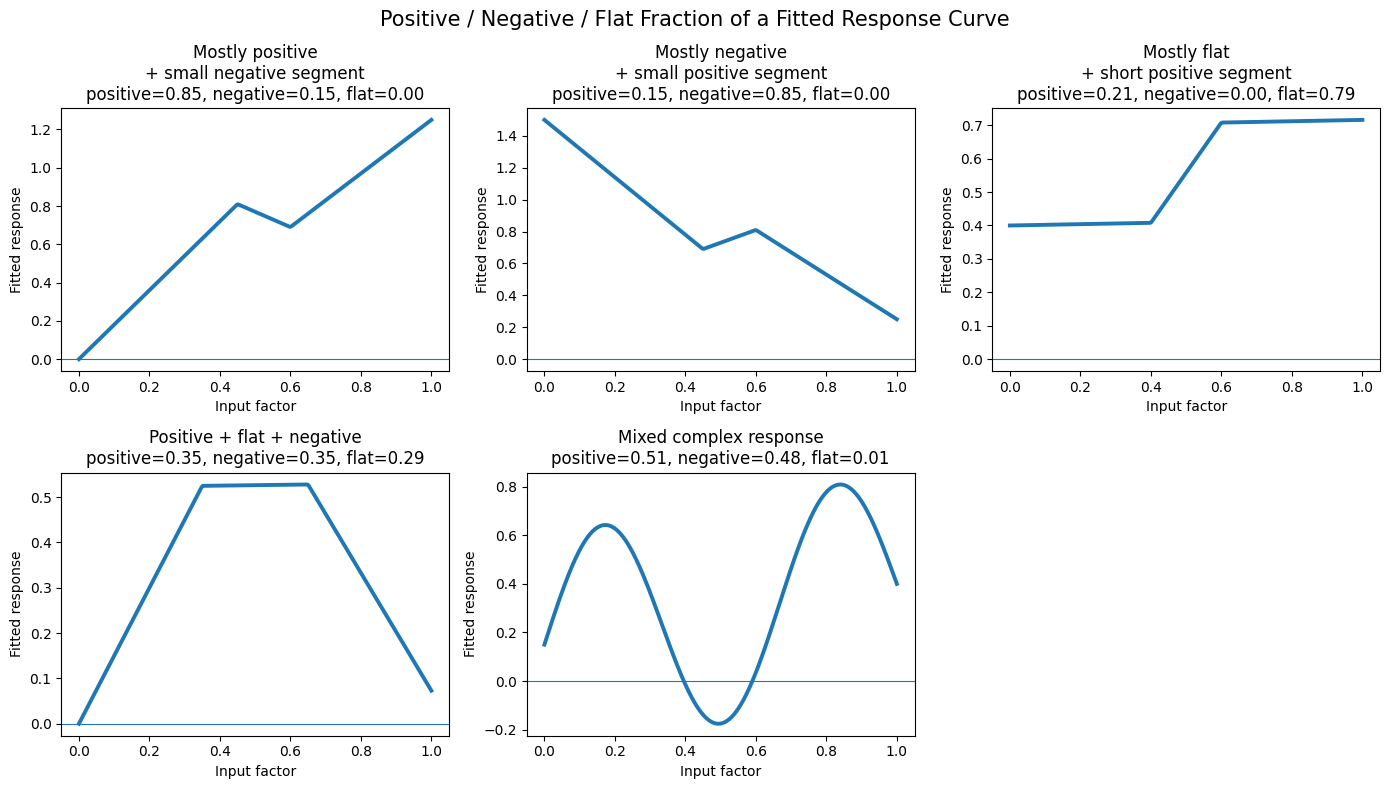

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Calculate positive / negative / flat fractions
# ============================================================

def calculate_shape_fractions(x, y, slope_tol=0.05):
    """
    Calculate the proportion of the fitted curve that is increasing,
    decreasing, or approximately flat.

    positive_fraction + negative_fraction + flat_fraction = 1
    """

    slopes = np.gradient(y, x)

    positive_fraction = np.mean(slopes > slope_tol)
    negative_fraction = np.mean(slopes < -slope_tol)
    flat_fraction = np.mean(np.abs(slopes) <= slope_tol)

    return positive_fraction, negative_fraction, flat_fraction, slopes


# ============================================================
# 2. Generate curves with different local slope compositions
# ============================================================

def generate_piecewise_curve(x, pattern="mostly_positive"):
    """
    Generate example fitted curves with different combinations of
    positive, negative, and flat local segments.
    """

    y = np.zeros_like(x)

    if pattern == "mostly_positive":
        # Most of the curve increases, with a short decreasing segment
        y = np.piecewise(
            x,
            [
                x < 0.45,
                (x >= 0.45) & (x < 0.60),
                x >= 0.60
            ],
            [
                lambda x: 1.8 * x,
                lambda x: 1.8 * 0.45 - 0.8 * (x - 0.45),
                lambda x: 1.8 * 0.45 - 0.8 * 0.15 + 1.4 * (x - 0.60)
            ]
        )

    elif pattern == "mostly_negative":
        # Most of the curve decreases, with a short increasing segment
        y = np.piecewise(
            x,
            [
                x < 0.45,
                (x >= 0.45) & (x < 0.60),
                x >= 0.60
            ],
            [
                lambda x: -1.8 * x + 1.5,
                lambda x: -1.8 * 0.45 + 1.5 + 0.8 * (x - 0.45),
                lambda x: -1.8 * 0.45 + 1.5 + 0.8 * 0.15 - 1.4 * (x - 0.60)
            ]
        )

    elif pattern == "mostly_flat":
        # Most of the curve is almost flat, with one short increasing segment
        y = np.piecewise(
            x,
            [
                x < 0.40,
                (x >= 0.40) & (x < 0.60),
                x >= 0.60
            ],
            [
                lambda x: 0.4 + 0.02 * x,
                lambda x: 0.4 + 0.02 * 0.40 + 1.5 * (x - 0.40),
                lambda x: 0.4 + 0.02 * 0.40 + 1.5 * 0.20 + 0.02 * (x - 0.60)
            ]
        )

    elif pattern == "positive_flat_negative":
        # First increasing, then flat, then decreasing
        y = np.piecewise(
            x,
            [
                x < 0.35,
                (x >= 0.35) & (x < 0.65),
                x >= 0.65
            ],
            [
                lambda x: 1.5 * x,
                lambda x: 1.5 * 0.35 + 0.01 * (x - 0.35),
                lambda x: 1.5 * 0.35 + 0.01 * 0.30 - 1.3 * (x - 0.65)
            ]
        )

    elif pattern == "mixed_complex":
        # Several alternating positive, negative, and flat parts
        y = (
            0.45 * np.sin(3 * np.pi * x)
            + 0.25 * x
            + 0.15
        )

    else:
        raise ValueError("Unknown pattern")

    return y


# ============================================================
# 3. Plot examples
# ============================================================

x = np.linspace(0, 1, 300)

patterns = [
    ("Mostly positive\n+ small negative segment", "mostly_positive"),
    ("Mostly negative\n+ small positive segment", "mostly_negative"),
    ("Mostly flat\n+ short positive segment", "mostly_flat"),
    ("Positive + flat + negative", "positive_flat_negative"),
    ("Mixed complex response", "mixed_complex"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

slope_tol = 0.05

for ax, (title, pattern) in zip(axes, patterns):

    y = generate_piecewise_curve(x, pattern)

    pos_frac, neg_frac, flat_frac, slopes = calculate_shape_fractions(
        x, y,
        slope_tol=slope_tol
    )

    ax.plot(x, y, linewidth=2.8)

    ax.set_title(
        f"{title}\n"
        f"positive={pos_frac:.2f}, negative={neg_frac:.2f}, flat={flat_frac:.2f}"
    )

    ax.set_xlabel("Input factor")
    ax.set_ylabel("Fitted response")

    # Optional: mark zero reference
    ax.axhline(0, linewidth=0.8)

# Hide empty panel
axes[-1].axis("off")

plt.suptitle(
    "Positive / Negative / Flat Fraction of a Fitted Response Curve",
    fontsize=15
)

plt.tight_layout()
plt.show()

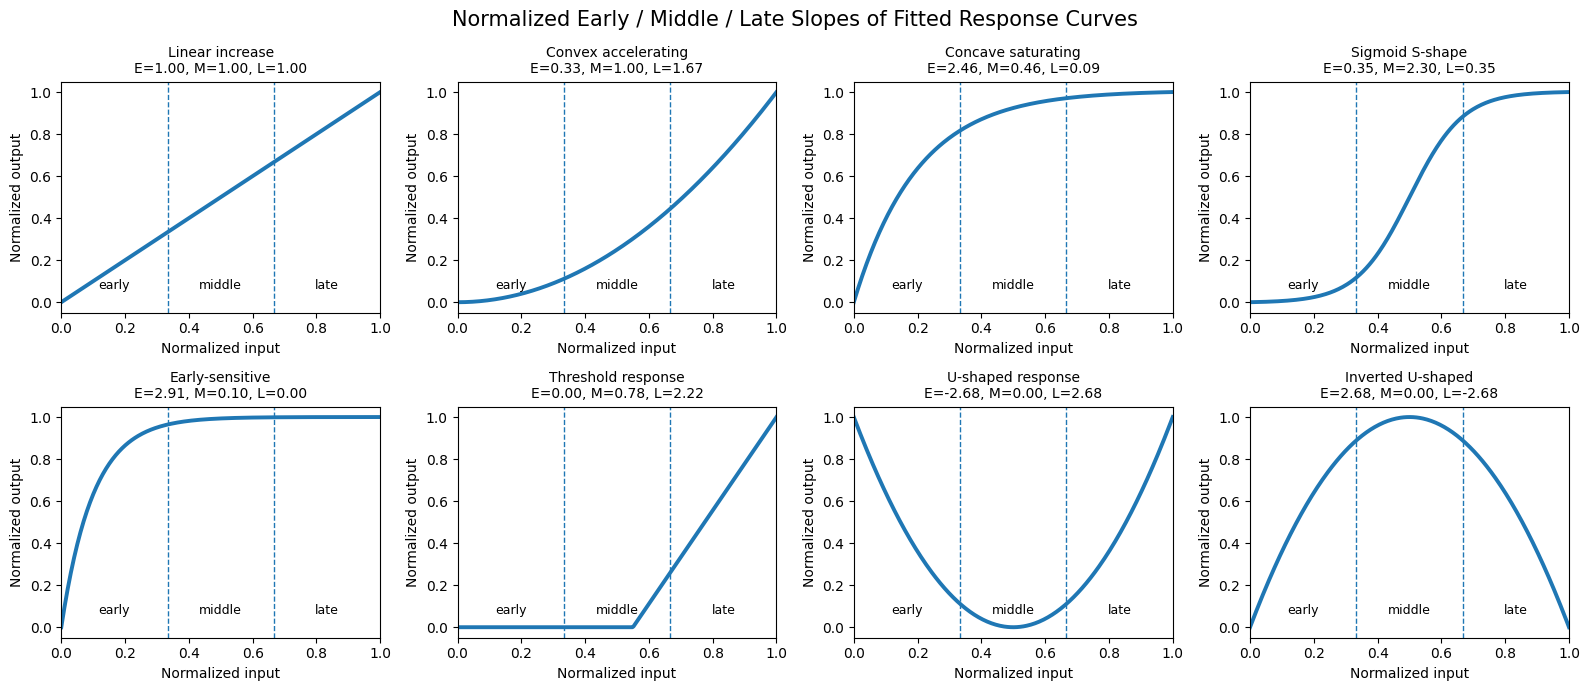

In [13]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Normalize x and y to [0, 1]
# ============================================================

def minmax_normalize(arr):
    arr = np.asarray(arr)

    if arr.max() == arr.min():
        return np.zeros_like(arr)

    return (arr - arr.min()) / (arr.max() - arr.min())


# ============================================================
# 2. Calculate normalized early / middle / late slopes
# ============================================================

def calculate_normalized_stage_slopes(x, y):
    """
    Calculate early / middle / late slopes after rescaling
    both x and y to [0, 1].

    The three slopes are dimensionless and comparable across variables.
    """

    x_norm = minmax_normalize(x)
    y_norm = minmax_normalize(y)

    n = len(x_norm)

    # Divide domain into three equal parts by x range
    early_mask = x_norm <= 1 / 3
    middle_mask = (x_norm > 1 / 3) & (x_norm <= 2 / 3)
    late_mask = x_norm > 2 / 3

    def segment_slope(x_seg, y_seg):
        """
        Mean slope over one segment, using endpoint difference.
        """
        if len(x_seg) < 2:
            return np.nan

        dx = x_seg[-1] - x_seg[0]
        dy = y_seg[-1] - y_seg[0]

        if dx == 0:
            return np.nan

        return dy / dx

    early_slope = segment_slope(x_norm[early_mask], y_norm[early_mask])
    middle_slope = segment_slope(x_norm[middle_mask], y_norm[middle_mask])
    late_slope = segment_slope(x_norm[late_mask], y_norm[late_mask])

    return early_slope, middle_slope, late_slope, x_norm, y_norm


# ============================================================
# 3. Generate typical response curves
# ============================================================

x = np.linspace(0, 1, 300)

curve_examples = {
    "Linear increase": x,
    "Convex accelerating": x**2,
    "Concave saturating": 1 - np.exp(-5 * x),
    "Sigmoid S-shape": 1 / (1 + np.exp(-12 * (x - 0.5))),
    "Early-sensitive": 1 - np.exp(-10 * x),
    "Threshold response": np.where(x < 0.55, 0.1, 0.1 + 2.0 * (x - 0.55)),
    "U-shaped response": 4 * (x - 0.5)**2,
    "Inverted U-shaped": -4 * (x - 0.5)**2 + 1,
}


# ============================================================
# 4. Plot
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for ax, (title, y) in zip(axes, curve_examples.items()):

    early, middle, late, x_norm, y_norm = calculate_normalized_stage_slopes(x, y)

    ax.plot(x_norm, y_norm, linewidth=2.8)

    # Stage boundaries
    ax.axvline(1/3, linestyle="--", linewidth=1)
    ax.axvline(2/3, linestyle="--", linewidth=1)

    # Light background labels
    ax.text(1/6, 0.05, "early", ha="center", va="bottom", fontsize=9)
    ax.text(0.50, 0.05, "middle", ha="center", va="bottom", fontsize=9)
    ax.text(5/6, 0.05, "late", ha="center", va="bottom", fontsize=9)

    ax.set_title(
        f"{title}\n"
        f"E={early:.2f}, M={middle:.2f}, L={late:.2f}",
        fontsize=10
    )

    ax.set_xlabel("Normalized input")
    ax.set_ylabel("Normalized output")

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle(
    "Normalized Early / Middle / Late Slopes of Fitted Response Curves",
    fontsize=15
)

plt.tight_layout()
plt.show()

SD(y_model) = 0.376
amplitude_norm = 3.108
net_change_norm = 2.940
total_variation_norm = 5.448


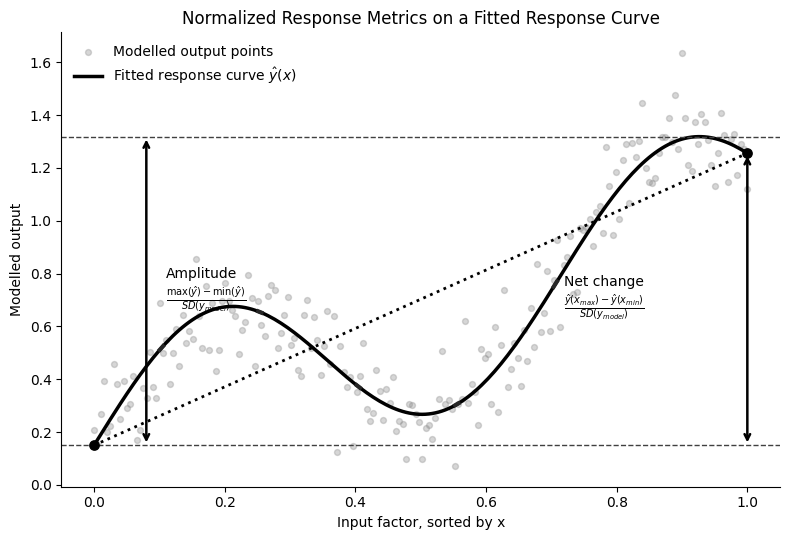

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Example data and fitted curve
# ============================================================

np.random.seed(42)

x = np.linspace(0, 1, 200)

# A fitted response curve with both increase and decrease
y_fit = (
    0.35 * np.sin(2.8 * np.pi * x)
    + 0.9 * x
    + 0.15
)

# Observed/modelled output points around the fitted curve
y_model = y_fit + np.random.normal(0, 0.12, len(x))

# Standard deviation of modelled output
sd_y_model = np.std(y_model, ddof=1)

# ============================================================
# 2. Metrics
# ============================================================

amplitude_norm = (np.max(y_fit) - np.min(y_fit)) / sd_y_model

net_change_norm = (y_fit[-1] - y_fit[0]) / sd_y_model

total_variation_norm = np.sum(np.abs(np.diff(y_fit))) / sd_y_model

print(f"SD(y_model) = {sd_y_model:.3f}")
print(f"amplitude_norm = {amplitude_norm:.3f}")
print(f"net_change_norm = {net_change_norm:.3f}")
print(f"total_variation_norm = {total_variation_norm:.3f}")


# ============================================================
# 3. Key points for annotation
# ============================================================

idx_max = np.argmax(y_fit)
idx_min = np.argmin(y_fit)

x_min_input = x[0]
x_max_input = x[-1]

y_at_xmin = y_fit[0]
y_at_xmax = y_fit[-1]

y_max = y_fit[idx_max]
y_min = y_fit[idx_min]


# ============================================================
# 4. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

# Scatter and fitted curve
ax.scatter(
    x, y_model,
    s=18,
    alpha=0.35,
    color="0.55",
    label="Modelled output points"
)

ax.plot(
    x, y_fit,
    linewidth=2.5,
    color="black",
    label=r"Fitted response curve $\hat{y}(x)$"
)

# ------------------------------------------------------------
# Amplitude: max(y_hat) - min(y_hat)
# ------------------------------------------------------------

ax.axhline(y_max, linestyle="--", linewidth=1, color="0.25")
ax.axhline(y_min, linestyle="--", linewidth=1, color="0.25")

x_amp = 0.08
ax.annotate(
    "",
    xy=(x_amp, y_max),
    xytext=(x_amp, y_min),
    arrowprops=dict(arrowstyle="<->", linewidth=1.8, color="black")
)

ax.text(
    x_amp + 0.03,
    (y_max + y_min) / 2,
    r"Amplitude" "\n"
    r"$\frac{\max(\hat{y})-\min(\hat{y})}{SD(y_{model})}$",
    va="center",
    fontsize=10
)

# ------------------------------------------------------------
# Net change: y_hat(xmax) - y_hat(xmin)
# ------------------------------------------------------------

ax.scatter(
    [x_min_input, x_max_input],
    [y_at_xmin, y_at_xmax],
    color="black",
    s=45,
    zorder=5
)

ax.plot(
    [x_min_input, x_max_input],
    [y_at_xmin, y_at_xmax],
    linestyle=":",
    linewidth=2,
    color="black"
)

ax.annotate(
    "",
    xy=(x_max_input, y_at_xmax),
    xytext=(x_max_input, y_at_xmin),
    arrowprops=dict(arrowstyle="<->", linewidth=1.8, color="black")
)

ax.text(
    x_max_input - 0.28,
    (y_at_xmin + y_at_xmax) / 2,
    r"Net change" "\n"
    r"$\frac{\hat{y}(x_{max})-\hat{y}(x_{min})}{SD(y_{model})}$",
    va="center",
    fontsize=10
)

# ------------------------------------------------------------
# Total variation: sum of absolute changes along fitted curve
# ------------------------------------------------------------

# Mark a few small vertical changes along the curve
sample_idx = np.linspace(20, 170, 6, dtype=int)

for i in sample_idx[:-1]:
    ax.plot(
        [x[i], x[i + 1]],
        [y_fit[i], y_fit[i + 1]],
        linewidth=3,
        color="0.15"
    )

# ax.text(
#     0.33,
#     y_min - 0.23,
#     r"Total variation" "\n"
#     r"$\frac{\sum_{i=1}^{n-1}|\hat{y}(x_{i+1})-\hat{y}(x_i)|}{SD(y_{model})}$",
#     fontsize=10,
#     ha="center"
# )

# ------------------------------------------------------------
# Clean formatting
# ------------------------------------------------------------

ax.set_xlabel("Input factor, sorted by x")
ax.set_ylabel("Modelled output")
ax.set_title("Normalized Response Metrics on a Fitted Response Curve")

ax.legend(frameon=False, loc="upper left")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

SD(y_model) = 0.421
Amplitude_norm = 2.365
Net_change_norm = 2.365
Total_variation_norm = 2.365


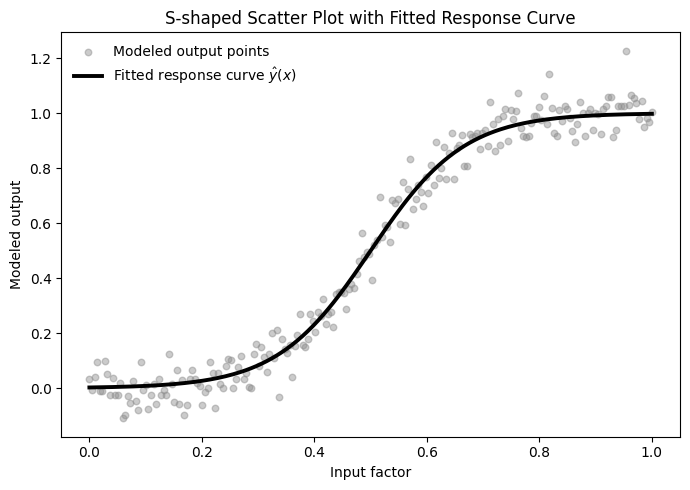

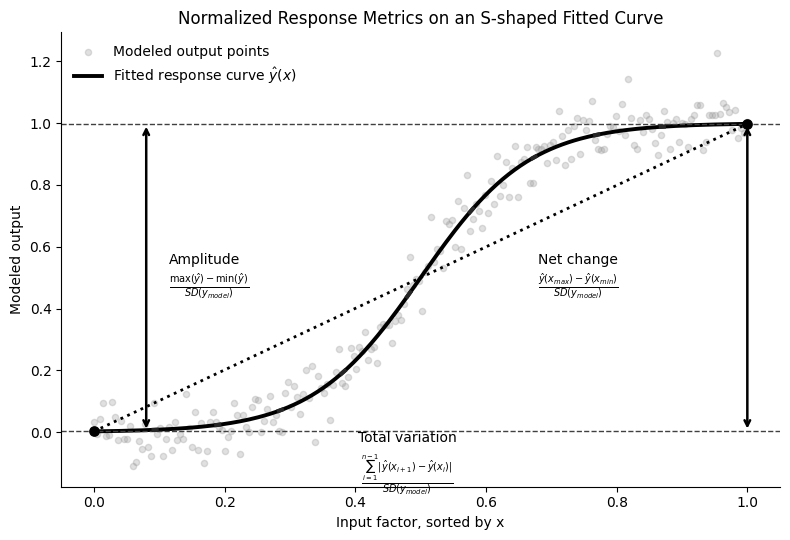

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Generate S-shaped scatter data and fitted response curve
# ============================================================

np.random.seed(42)

x = np.linspace(0, 1, 220)

# S-shaped fitted response curve
y_fit = 1 / (1 + np.exp(-12 * (x - 0.5)))

# Add noise to generate scatter points
noise = np.random.normal(0, 0.06, len(x))
y_scatter = y_fit + noise

# Standard deviation of modeled output
sd_y_model = np.std(y_scatter, ddof=1)

# Metrics
amplitude_norm = (np.max(y_fit) - np.min(y_fit)) / sd_y_model
net_change_norm = (y_fit[-1] - y_fit[0]) / sd_y_model
total_variation_norm = np.sum(np.abs(np.diff(y_fit))) / sd_y_model

print(f"SD(y_model) = {sd_y_model:.3f}")
print(f"Amplitude_norm = {amplitude_norm:.3f}")
print(f"Net_change_norm = {net_change_norm:.3f}")
print(f"Total_variation_norm = {total_variation_norm:.3f}")


# ============================================================
# Figure 1: simple S-shaped scatter + fitted curve
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    x, y_scatter,
    s=22,
    alpha=0.45,
    color="0.55",
    label="Modeled output points"
)

plt.plot(
    x, y_fit,
    linewidth=2.8,
    color="black",
    label=r"Fitted response curve $\hat{y}(x)$"
)

plt.xlabel("Input factor")
plt.ylabel("Modeled output")
plt.title("S-shaped Scatter Plot with Fitted Response Curve")

plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# ============================================================
# Figure 2: concept figure with three normalized metrics
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.scatter(
    x, y_scatter,
    s=20,
    alpha=0.30,
    color="0.60",
    label="Modeled output points"
)

ax.plot(
    x, y_fit,
    linewidth=2.8,
    color="black",
    label=r"Fitted response curve $\hat{y}(x)$"
)

# Key values
idx_max = np.argmax(y_fit)
idx_min = np.argmin(y_fit)

x_min_input = x[0]
x_max_input = x[-1]

y_at_xmin = y_fit[0]
y_at_xmax = y_fit[-1]

y_max = y_fit[idx_max]
y_min = y_fit[idx_min]


# ------------------------------------------------------------
# Amplitude: max(y_hat) - min(y_hat), normalized by SD(y_model)
# ------------------------------------------------------------

ax.axhline(y_max, linestyle="--", linewidth=1, color="0.25")
ax.axhline(y_min, linestyle="--", linewidth=1, color="0.25")

x_amp = 0.08

ax.annotate(
    "",
    xy=(x_amp, y_max),
    xytext=(x_amp, y_min),
    arrowprops=dict(arrowstyle="<->", linewidth=1.8, color="black")
)

ax.text(
    x_amp + 0.035,
    (y_max + y_min) / 2,
    "Amplitude\n"
    r"$\frac{\max(\hat{y})-\min(\hat{y})}{SD(y_{model})}$",
    va="center",
    fontsize=10
)


# ------------------------------------------------------------
# Net change: y_hat(xmax) - y_hat(xmin), normalized by SD(y_model)
# ------------------------------------------------------------

ax.scatter(
    [x_min_input, x_max_input],
    [y_at_xmin, y_at_xmax],
    color="black",
    s=45,
    zorder=5
)

ax.plot(
    [x_min_input, x_max_input],
    [y_at_xmin, y_at_xmax],
    linestyle=":",
    linewidth=2,
    color="black"
)

ax.annotate(
    "",
    xy=(x_max_input, y_at_xmax),
    xytext=(x_max_input, y_at_xmin),
    arrowprops=dict(arrowstyle="<->", linewidth=1.8, color="black")
)

ax.text(
    0.68,
    (y_at_xmin + y_at_xmax) / 2,
    "Net change\n"
    r"$\frac{\hat{y}(x_{max})-\hat{y}(x_{min})}{SD(y_{model})}$",
    va="center",
    fontsize=10
)


# ------------------------------------------------------------
# Total variation: sum of absolute changes along fitted curve
# ------------------------------------------------------------

# Draw several small local change segments along the curve
sample_idx = np.linspace(20, 190, 9, dtype=int)

for i in sample_idx:
    ax.plot(
        [x[i], x[i + 1]],
        [y_fit[i], y_fit[i + 1]],
        linewidth=3,
        color="0.15"
    )

ax.text(
    0.48,
    y_min - 0.18,
    "Total variation\n"
    r"$\frac{\sum_{i=1}^{n-1}|\hat{y}(x_{i+1})-\hat{y}(x_i)|}{SD(y_{model})}$",
    fontsize=10,
    ha="center"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_xlabel("Input factor, sorted by x")
ax.set_ylabel("Modeled output")
ax.set_title("Normalized Response Metrics on an S-shaped Fitted Curve")

ax.legend(frameon=False, loc="upper left")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

SD(y_model) = 0.421
SD(residuals) = 0.057
Amplitude_norm = 2.365
Net_change_norm = 2.365
Total_variation_norm = 2.365


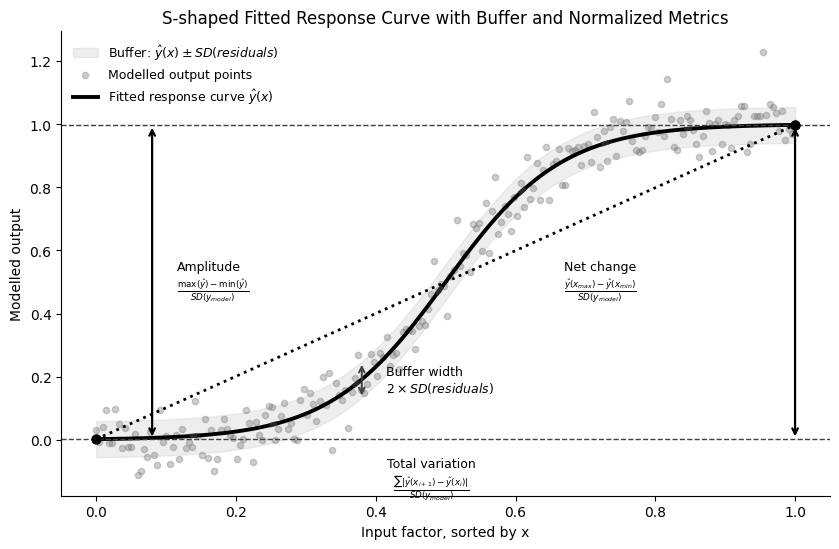

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Generate S-shaped scatter data and fitted response curve
# ============================================================

np.random.seed(42)

x = np.linspace(0, 1, 220)

# S-shaped fitted response curve
y_fit = 1 / (1 + np.exp(-12 * (x - 0.5)))

# Scatter points around the fitted curve
noise = np.random.normal(0, 0.06, len(x))
y_scatter = y_fit + noise

# ============================================================
# 2. Buffer based on residual standard deviation
# ============================================================

residuals = y_scatter - y_fit
resid_sd = np.std(residuals, ddof=1)

buffer_k = 1.0
upper_buffer = y_fit + buffer_k * resid_sd
lower_buffer = y_fit - buffer_k * resid_sd

# ============================================================
# 3. Normalized response metrics
# ============================================================

sd_y_model = np.std(y_scatter, ddof=1)

amplitude_norm = (np.max(y_fit) - np.min(y_fit)) / sd_y_model

net_change_norm = (y_fit[-1] - y_fit[0]) / sd_y_model

total_variation_norm = np.sum(np.abs(np.diff(y_fit))) / sd_y_model

print(f"SD(y_model) = {sd_y_model:.3f}")
print(f"SD(residuals) = {resid_sd:.3f}")
print(f"Amplitude_norm = {amplitude_norm:.3f}")
print(f"Net_change_norm = {net_change_norm:.3f}")
print(f"Total_variation_norm = {total_variation_norm:.3f}")

# ============================================================
# 4. Key points
# ============================================================

idx_max = np.argmax(y_fit)
idx_min = np.argmin(y_fit)

y_max = y_fit[idx_max]
y_min = y_fit[idx_min]

x_min_input = x[0]
x_max_input = x[-1]

y_at_xmin = y_fit[0]
y_at_xmax = y_fit[-1]

# ============================================================
# 5. Plot concept figure
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 5.6))

# Buffer band
ax.fill_between(
    x,
    lower_buffer,
    upper_buffer,
    alpha=0.18,
    color="0.65",
    label=r"Buffer: $\hat{y}(x) \pm SD(residuals)$"
)

# Scatter points
ax.scatter(
    x,
    y_scatter,
    s=20,
    alpha=0.35,
    color="0.45",
    label="Modelled output points"
)

# Fitted curve
ax.plot(
    x,
    y_fit,
    linewidth=2.8,
    color="black",
    label=r"Fitted response curve $\hat{y}(x)$"
)

# ------------------------------------------------------------
# Amplitude
# ------------------------------------------------------------

ax.axhline(y_max, linestyle="--", linewidth=1, color="0.25")
ax.axhline(y_min, linestyle="--", linewidth=1, color="0.25")

x_amp = 0.08

ax.annotate(
    "",
    xy=(x_amp, y_max),
    xytext=(x_amp, y_min),
    arrowprops=dict(arrowstyle="<->", linewidth=1.6, color="black")
)

ax.text(
    x_amp + 0.035,
    (y_max + y_min) / 2,
    "Amplitude\n"
    r"$\frac{\max(\hat{y})-\min(\hat{y})}{SD(y_{model})}$",
    va="center",
    fontsize=9
)

# ------------------------------------------------------------
# Net change: endpoint-to-endpoint change
# ------------------------------------------------------------

ax.scatter(
    [x_min_input, x_max_input],
    [y_at_xmin, y_at_xmax],
    color="black",
    s=42,
    zorder=5
)

ax.plot(
    [x_min_input, x_max_input],
    [y_at_xmin, y_at_xmax],
    linestyle=":",
    linewidth=2,
    color="black"
)

ax.annotate(
    "",
    xy=(x_max_input, y_at_xmax),
    xytext=(x_max_input, y_at_xmin),
    arrowprops=dict(arrowstyle="<->", linewidth=1.6, color="black")
)

ax.text(
    0.67,
    (y_at_xmin + y_at_xmax) / 2,
    "Net change\n"
    r"$\frac{\hat{y}(x_{max})-\hat{y}(x_{min})}{SD(y_{model})}$",
    va="center",
    fontsize=9
)

# ------------------------------------------------------------
# Total variation: local absolute changes along fitted curve
# ------------------------------------------------------------

sample_idx = np.linspace(30, 185, 7, dtype=int)

for i in sample_idx:
    ax.plot(
        [x[i], x[i + 1]],
        [y_fit[i], y_fit[i + 1]],
        linewidth=3.2,
        color="0.15"
    )

ax.text(
    0.48,
    y_min - 0.17,
    "Total variation\n"
    r"$\frac{\sum |\hat{y}(x_{i+1})-\hat{y}(x_i)|}{SD(y_{model})}$",
    fontsize=9,
    ha="center"
)

# ------------------------------------------------------------
# Buffer annotation
# ------------------------------------------------------------

x_buf = 0.38
idx_buf = np.argmin(np.abs(x - x_buf))

ax.annotate(
    "",
    xy=(x_buf, upper_buffer[idx_buf]),
    xytext=(x_buf, lower_buffer[idx_buf]),
    arrowprops=dict(arrowstyle="<->", linewidth=1.4, color="0.25")
)

ax.text(
    x_buf + 0.035,
    y_fit[idx_buf],
    "Buffer width\n"
    r"$2 \times SD(residuals)$",
    va="center",
    fontsize=9
)

# ============================================================
# 6. Formatting
# ============================================================

ax.set_xlabel("Input factor, sorted by x")
ax.set_ylabel("Modelled output")
ax.set_title("S-shaped Fitted Response Curve with Buffer and Normalized Metrics")

ax.legend(frameon=False, loc="upper left", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

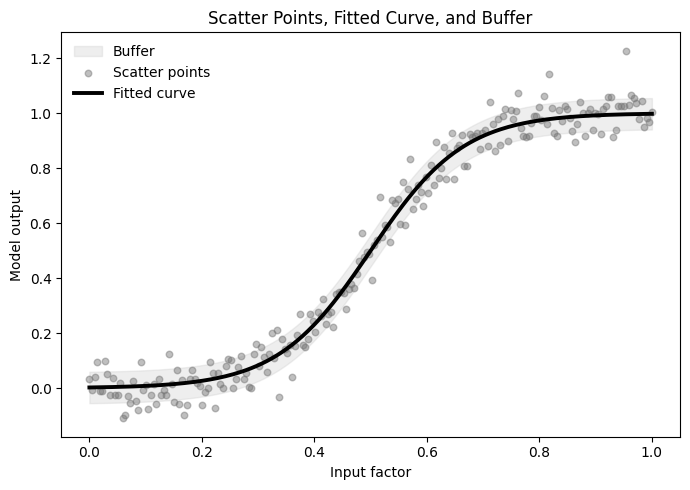

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Generate S-shaped scatter data and fitted response curve
# ============================================================

np.random.seed(42)

x = np.linspace(0, 1, 220)

# Fitted S-shaped response curve
y_fit = 1 / (1 + np.exp(-12 * (x - 0.5)))

# Scatter points around fitted curve
noise = np.random.normal(0, 0.06, len(x))
y_scatter = y_fit + noise

# Buffer based on residual standard deviation
residuals = y_scatter - y_fit
resid_sd = np.std(residuals, ddof=1)

buffer_k = 1.0
upper_buffer = y_fit + buffer_k * resid_sd
lower_buffer = y_fit - buffer_k * resid_sd

# ============================================================
# Plot: points + fitted line + buffer
# ============================================================

plt.figure(figsize=(7, 5))

plt.fill_between(
    x,
    lower_buffer,
    upper_buffer,
    alpha=0.25,
    color="0.75",
    label="Buffer"
)

plt.scatter(
    x,
    y_scatter,
    s=22,
    alpha=0.45,
    color="0.45",
    label="Scatter points"
)

plt.plot(
    x,
    y_fit,
    linewidth=2.8,
    color="black",
    label="Fitted curve"
)

plt.xlabel("Input factor")
plt.ylabel("Model output")
plt.title("Scatter Points, Fitted Curve, and Buffer")

plt.legend(frameon=False)
plt.tight_layout()
plt.show()